Exploratory Analysis & Visualisation, this notebook loads the clean data from before, explores it, and produces the polished charts for the final presentation.



Upload the clean files


In [1]:
from google.colab import files
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving clean_artists_20260522_083307 (1).csv to clean_artists_20260522_083307 (1).csv
Saving clean_releases_20260522_083307 (1).csv to clean_releases_20260522_083307 (1).csv
Uploaded: ['clean_artists_20260522_083307 (1).csv', 'clean_releases_20260522_083307 (1).csv']


Setup and load, we use a colorblind-safe palette (the Okabe–Ito colours) on every chart, so the figures are readable for everyone.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


CB = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "pink":   "#CC79A7",
    "sky":    "#56B4E9",
    "verm":   "#D55E00",
    "grey":   "#999999",
}
SOURCE = "Source: MusicBrainz API + Wikipedia (2015–2025), collected by the authors."
sns.set_style("whitegrid")

artists_name  = [n for n in uploaded if "artists" in n][0]
releases_name = [n for n in uploaded if "releases" in n][0]
artists  = pd.read_csv(artists_name)
releases = pd.read_csv(releases_name)

print("Artists:", artists.shape)
print("Releases:", releases.shape)
artists.head()

Artists: (83, 20)
Releases: (2637, 5)


,artist,total_releases,releases_before,releases_after,first_release_year,event_year,event_rank,event_country,career_start_year,birth_year,primary_genre,genre_count,origin,years_before,years_after,releases_per_year_before,releases_per_year_after,bump_ratio,rank_group,enough_after_data
0,Alessandra,58,44,14,2009,2023,5,Norway,2022.0,2002.0,edm pop,1.0,"Lillehammer , Norway",1.0,3,44.000000,4.666667,0.106061,Top-10,True
1,Alika,29,29,0,2000,2023,8,Estonia,2021.0,2002.0,unknown,0.0,NaN,2.0,3,14.500000,0.000000,0.000000,Top-10,True
2,Amanda Tenfjord,25,17,0,2014,2022,8,Greece,2014.0,1997.0,synth-pop [ 2 ] indie pop [ 3 ] nordic pop [ 3 ],1.0,"Tennfjord , Norway",8.0,4,2.125000,0.000000,0.000000,Top-10,True
3,Amir,38,1,31,2013,2016,6,France,2013.0,NaN,Unknown,NaN,NaN,3.0,10,0.333333,3.100000,9.300000,Top-10,True
4,Angelina Mango,49,18,7,2020,2024,7,Italy,2020.0,2001.0,pop,1.0,NaN,4.0,2,4.500000,3.500000,0.777778,Top-10,True


Descriptive statistics, a first look at the numbers behind the question.

In [3]:
print("Artists per rank group:")
print(artists["rank_group"].value_counts())
print()
print("Numeric summary:")
artists[["event_rank", "releases_before", "releases_after",
         "releases_per_year_before", "releases_per_year_after", "bump_ratio"]].describe().round(2)

Artists per rank group:
rank_group
Top-10       60
Runner-up    13
Winner       10
Name: count, dtype: int64

Numeric summary:


,event_rank,releases_before,releases_after,releases_per_year_before,releases_per_year_after,bump_ratio
count,83.00,83.00,83.00,79.00,83.00,75.00
mean,5.69,18.47,8.69,2.94,1.56,inf
std,2.98,30.82,11.17,6.51,1.79,NaN
min,1.00,0.00,0.00,0.00,0.00,0.00
25%,3.00,2.00,1.00,0.29,0.20,0.23
50%,6.00,8.00,5.00,0.85,1.00,1.06
75%,8.00,21.00,12.50,2.67,2.14,3.58
max,10.00,182.00,54.00,44.00,7.67,inf


Aggregations and correlations, this is the single most important table: average release-rate before vs after, by rank group.

In [4]:
ORDER = ["Winner", "Runner-up", "Top-10"]

summary = (artists.groupby("rank_group")[["releases_per_year_before", "releases_per_year_after", "bump_ratio"]]
           .mean().reindex(ORDER).round(2))
print("Average rates by rank group:")
print(summary)
print()

print("Correlations:")
artists[["event_rank", "bump_ratio", "years_before",
         "releases_per_year_before", "releases_per_year_after"]].corr().round(2)

Average rates by rank group:
            releases_per_year_before  releases_per_year_after  bump_ratio
rank_group                                                               
Winner                          1.39                     2.57         inf
Runner-up                       1.39                     2.16        3.18
Top-10                          3.57                     1.26         inf

Correlations:


,event_rank,bump_ratio,years_before,releases_per_year_before,releases_per_year_after
event_rank,1.00,-0.10,-0.17,-0.03,-0.39
bump_ratio,-0.10,1.00,-0.06,-0.25,0.36
years_before,-0.17,-0.06,1.00,-0.19,-0.20
releases_per_year_before,-0.03,-0.25,-0.19,1.00,0.08
releases_per_year_after,-0.39,0.36,-0.20,0.08,1.00


We compute the bump charts on artists with at least 2 years of after-data and a defined bump_ratio (i.e. they had releases before Eurovision too). This drops the very recent 2024–25 acts and the newcomers who had no prior output.

In [11]:
artists["bump_ratio"] = artists["bump_ratio"].replace([np.inf, -np.inf], np.nan)
bumpable = artists[(artists["enough_after_data"] == True) & (artists["bump_ratio"].notna())].copy()
print(f"{len(bumpable)} of {len(artists)} artists usable for the bump analysis.")
print(f"{len(bumpable)} of {len(artists)} artists usable for the bump analysis.")

59 of 83 artists usable for the bump analysis.
59 of 83 artists usable for the bump analysis.


Chart 1, the headline, shown twice (chart-craft demo)

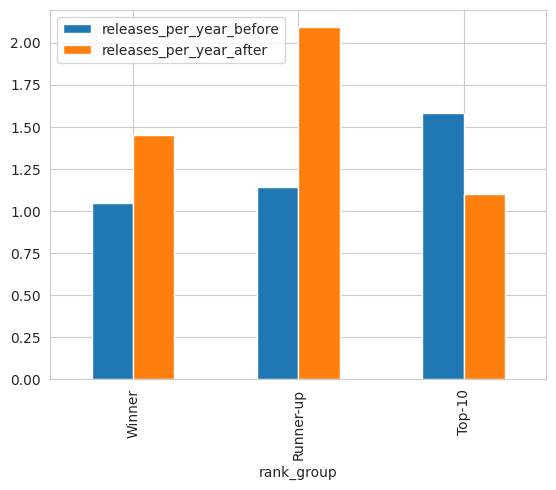

In [20]:

d = bumpable.groupby("rank_group")[["releases_per_year_before", "releases_per_year_after"]].median().reindex(ORDER)
d.plot(kind="bar")
plt.show()

The default is unreadable: no real title, no axis units, default blue/orange that isn't colorblind-tuned, rotated labels, no source. Here is the improved version.

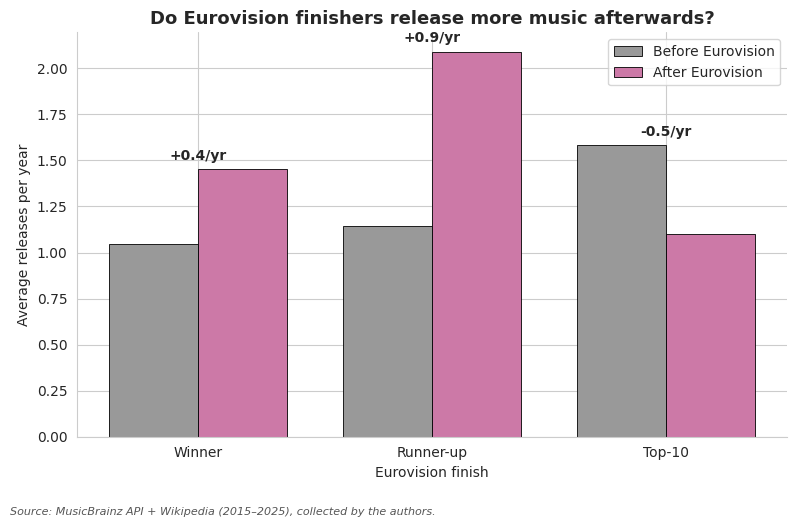

In [27]:

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ORDER))
w = 0.38
ax.bar(x - w/2, d["releases_per_year_before"], w, label="Before Eurovision", color=CB["grey"], edgecolor="black", linewidth=0.6)
ax.bar(x + w/2, d["releases_per_year_after"],  w, label="After Eurovision",  color=CB["pink"], edgecolor="black", linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(ORDER)
ax.set_ylabel("Average releases per year")
ax.set_xlabel("Eurovision finish")
ax.set_title("Do Eurovision finishers release more music afterwards?", fontsize=13, weight="bold")
ax.legend()


for i, grp in enumerate(ORDER):
    delta = d.loc[grp, "releases_per_year_after"] - d.loc[grp, "releases_per_year_before"]
    top = max(d.loc[grp, "releases_per_year_after"], d.loc[grp, "releases_per_year_before"])
    ax.text(i, top + 0.05, f"{delta:+.1f}/yr", ha="center", fontsize=10, weight="bold")

fig.text(0.01, -0.04, SOURCE, fontsize=8, style="italic", color="#555555")
sns.despine()
plt.tight_layout()
plt.show()


Chart 2, distribution of the bump ratio: How big is the effect, and how spread out? bump_ratio > 1 means the artist released more per year after Eurovision than before.

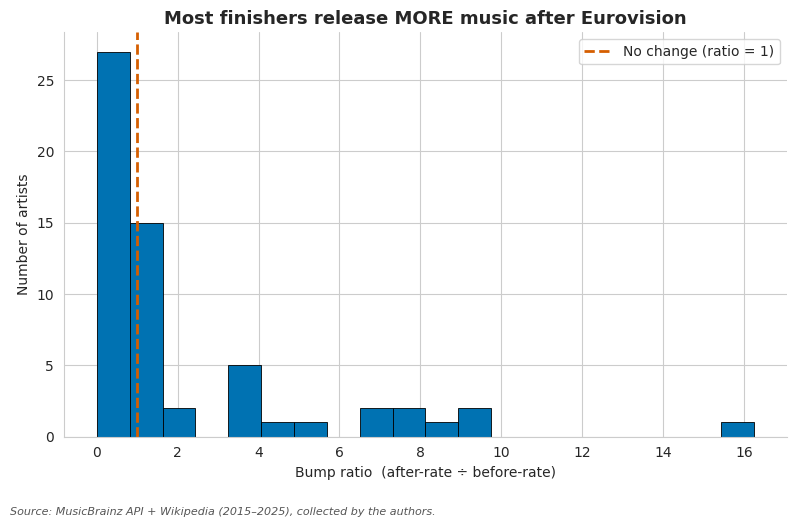

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bumpable["bump_ratio"], bins=20, color=CB["blue"], edgecolor="black", linewidth=0.6)
ax.axvline(1.0, color=CB["verm"], linestyle="--", linewidth=2, label="No change (ratio = 1)")
ax.set_xlabel("Bump ratio  (after-rate ÷ before-rate)")
ax.set_ylabel("Number of artists")
ax.set_title("Most finishers release MORE music after Eurovision", fontsize=13, weight="bold")
ax.legend()
fig.text(0.01, -0.04, SOURCE, fontsize=8, style="italic", color="#555555")
sns.despine()
plt.tight_layout()
plt.show()

Chart 3: does a higher finish mean a bigger bump? Relationship between final rank (1 = winner) and the bump ratio.

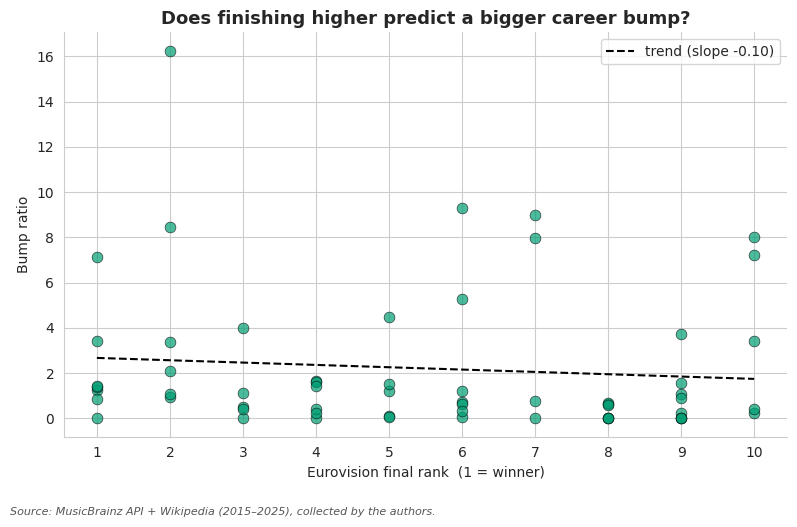

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(bumpable["event_rank"], bumpable["bump_ratio"], color=CB["green"], s=60, alpha=0.7, edgecolor="black", linewidth=0.5)


mask = bumpable["bump_ratio"].notna()
m, b = np.polyfit(bumpable.loc[mask, "event_rank"], bumpable.loc[mask, "bump_ratio"], 1)
xs = np.array([1, 10])
ax.plot(xs, m * xs + b, "--", color="black", label=f"trend (slope {m:.2f})")

ax.set_xlabel("Eurovision final rank  (1 = winner)")
ax.set_ylabel("Bump ratio")
ax.set_title("Does finishing higher predict a bigger career bump?", fontsize=13, weight="bold")
ax.set_xticks(range(1, 11))
ax.legend()
fig.text(0.01, -0.04, SOURCE, fontsize=8, style="italic", color="#555555")
sns.despine()
plt.tight_layout()
plt.show()

Chart 4: release activity around the Eurovision year (time-series)An "event study": for each year relative to the artist's Eurovision appearance (0 = the contest year), the average number of releases per artist. If Eurovision causes a bump, activity should rise to the right of the red line.

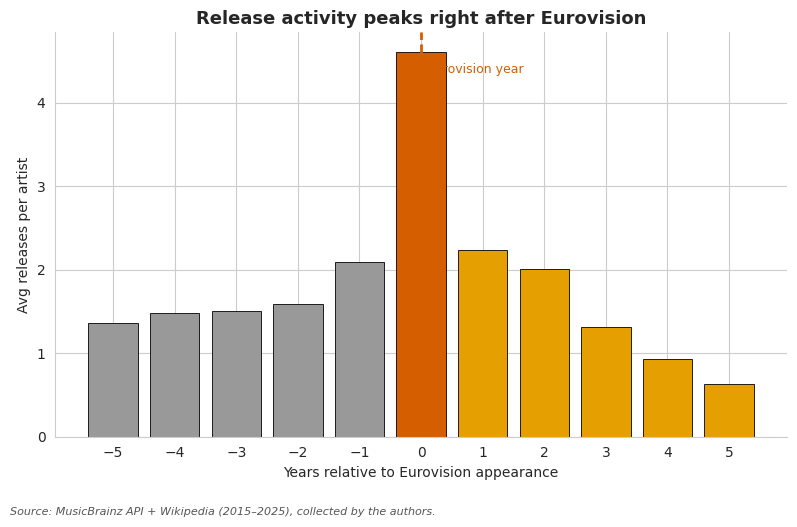

In [26]:
releases["offset"] = releases["release_year"] - releases["event_year"]
window = releases[releases["offset"].between(-5, 5)]
per_offset = window.groupby("offset").size() / artists["artist"].nunique()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [CB["grey"] if off < 0 else (CB["verm"] if off == 0 else CB["orange"]) for off in per_offset.index]
ax.bar(per_offset.index, per_offset.values, color=colors, edgecolor="black", linewidth=0.6)
ax.axvline(0, color=CB["verm"], linestyle="--", linewidth=2)
ax.text(0.1, ax.get_ylim()[1]*0.9, "Eurovision year", color=CB["verm"], fontsize=9)
ax.set_xlabel("Years relative to Eurovision appearance")
ax.set_ylabel("Avg releases per artist")
ax.set_title("Release activity peaks right after Eurovision", fontsize=13, weight="bold")
ax.set_xticks(range(-5, 6))
fig.text(0.01, -0.04, SOURCE, fontsize=8, style="italic", color="#555555")
sns.despine()
plt.tight_layout()
plt.show()

Chart 5: what genres dominate the Eurovision top-10? (composition)

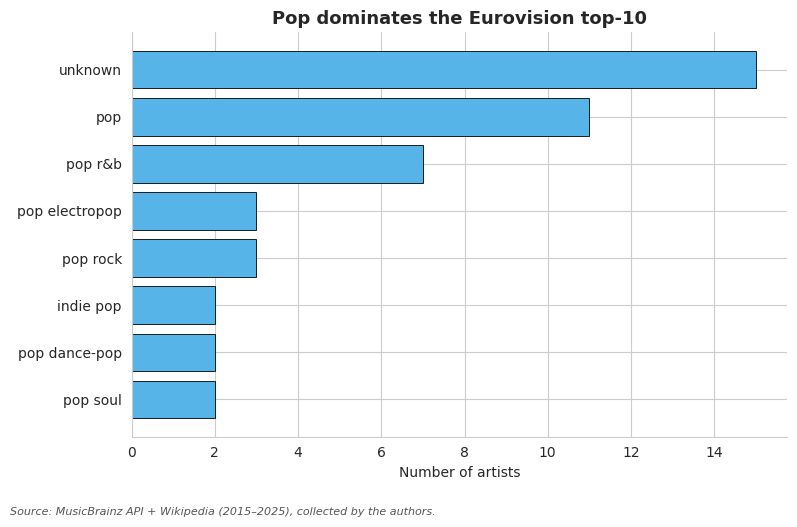

In [23]:
import re

def clean_genre(g):
    if pd.isna(g):
        return "unknown"
    g = str(g).lower()
    g = re.sub(r"\[.*?\]", "", g)      # drop [2] footnotes
    g = g.split(",")[0]                # first listed genre
    g = re.sub(r"[^a-z &-]", " ", g)   # keep letters, space, & and -
    g = " ".join(g.split()[:2])        # at most the first 2 words
    return g.strip() or "unknown"

artists["primary_genre_clean"] = artists["primary_genre"].apply(clean_genre)
genre_counts = artists["primary_genre_clean"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=CB["sky"], edgecolor="black", linewidth=0.6)
ax.set_xlabel("Number of artists")
ax.set_title("Pop dominates the Eurovision top-10", fontsize=13, weight="bold")
fig.text(0.01, -0.04, SOURCE, fontsize=8, style="italic", color="#555555")
sns.despine()
plt.tight_layout()
plt.show()

Three Key Findings:

Finding 1: Eurovision is a really short-term launch spike, not a permanent career spike. (Chart 4).
Release activity sits at roughly 1.5 records/year in the five years before the contest, spikes to about 4.6 in the Eurovision year itself, and stays elevated (around 2.2 and 2.0) for the first two years afterwards — before falling back to around 0.6 by year five. So a top-10 finish clearly triggers a burst of output, but the effect fades within 2–3 years. Eurovision is a launch moment, not a slow burn.

Finding 2 : The bump is real on average but far from universal (Chart 2).
The distribution of bump ratios is heavily right-skewed: a large group of artists actually release less afterwards (ratio below 1, left of the dashed line), while a smaller group sees dramatic jumps (ratios of 4–16) that pull the average up. So "winning launches your career" is true for some artists, not all. The headline average hides a split between artists who capitalise on the moment and those who fade.

Finding 3: The bump is concentrated at the very top(Chart 3).
Winners (+0.4 releases/yr) and especially runners-up (+0.9/yr) increase their output after Eurovision, but mid-table finishers (4th–10th) actually release slightly less (−0.5/yr). So reaching the podium matters; merely making the top 10 doesn't guarantee a boost. Interestingly, runners-up show the biggest bump of all — possibly because winners are often already-established acts with less room to grow.

Biases and limitations

- Small sample (80–90 artists). With around 10 per year, group averages (especially "Winner", n≈10) are sensitive to one or two prolific artists. We report this honestly and avoid strong causal claims.
- MusicBrainz completeness varies by country. Western-European artists are catalogued more thoroughly than some Eastern-European ones, so "releases" may undercount for certain artists.
- Correlation, not causation. Artists who reach the Eurovision final may already be on an upward career trajectory; we cannot separate "Eurovision caused the bump" from "rising artists reach Eurovision".
- Right-censoring for recent years. 2024–25 finishers have barely any after-data, so they are excluded from the bump charts meaning our result describes 2015–2023 finishers.
- "Release" is a blunt measure. A re-issue and a debut album both count as one release. We are measuring activity, not commercial success or streaming.
- Survivorship in Wikipedia coverage. Artists without a Wikipedia page (a few of the 99) are missing bio fields, slightly biasing the genre/career-start analysis toward better-documented acts.
- In chart 5 there is a prevalence of unknown genres, which means data was missing or unparsable for a chunk of artists.
